# Preprocesamiento de Datos para Machine Learning

El **preprocesamiento** es una de las fases más críticas en cualquier proyecto de Machine Learning. Los modelos aprenden patrones a partir de los datos, por lo que la calidad de los datos de entrada determina directamente la calidad de las predicciones.

En este notebook trabajaremos con datos de **Lending Club** (préstamos P2P) para construir un modelo que prediga si un préstamo será pagado o entrará en impago (`loan_status`).

**Dataset:** ~80,000 préstamos con 93+ variables originales.

In [1]:
import pandas as pd

df_train = pd.read_csv("data/df_train_small.csv")

Cargamos el dataset de entrenamiento. Es importante que todo el preprocesamiento se diseñe **exclusivamente** sobre el conjunto de train, para luego replicar las mismas transformaciones sobre test sin introducir *data leakage*.

## Pipeline de Preprocesamiento

El preprocesamiento sigue un orden lógico donde cada paso depende del anterior:

1. **Selección inicial de variables** — Eliminar variables irrelevantes o que causan *data leakage*
2. **Tratamiento de valores nulos (NaN)** — Decidir qué hacer con los datos faltantes
3. **Procesamiento de variables categóricas** — Convertirlas a formato numérico
   - Baja cardinalidad → One-Hot Encoding
   - Alta cardinalidad (texto libre) → Técnicas especiales (Target Encoding, embeddings...)
4. **Procesamiento de variables numéricas** — Normalización, transformación, outliers
5. **Feature Engineering** — Crear nuevas variables a partir de las existentes
6. **Feature Selection** — Eliminar variables que no aportan información al modelo

> **Importante:** Todo el preprocesamiento se diseña SOLO sobre el conjunto de **entrenamiento**. Luego se aplican las mismas transformaciones al conjunto de test para evitar *data leakage*.

---
## 1. Selección Inicial de Variables

Antes de cualquier transformación, debemos seleccionar qué variables tienen sentido como **predictoras**. Se descartan:

- **Identificadores** (`id`, `member_id`): No tienen valor predictivo
- **Variables post-concesión** (`funded_amnt`, `funded_amnt_inv`): Generan **data leakage** porque solo se conocen después de aprobar el préstamo — exactamente lo que queremos predecir
- **Variables redundantes o irrelevantes** según criterio de negocio

Usamos un fichero Excel donde previamente se ha clasificado cada variable como posible predictora o no, junto con el motivo de exclusión.

In [2]:
raw_predictors_vars = pd.read_excel("data/variables_withoutExperts.xlsx")
raw_predictors_vars.head()

,variable,categoria,descripcion,posible_predictora,motivo_exclusion
0,id,identificador,Identificador unico del prestamo,no,Identificador sin valor predictivo
1,member_id,identificador,Identificador unico del miembro,no,Identificador sin valor predictivo
2,loan_amnt,solicitud,Importe del prestamo solicitado,si,NaN
3,funded_amnt,post_concesion,Importe total financiado,no,Data leakage: conocido post-aprobacion
4,funded_amnt_inv,post_concesion,Importe financiado por inversores,no,Data leakage: conocido post-aprobacion


In [ ]:
raw_predictors_vars = ( raw_predictors_vars
                       .query("posible_predictora == 'si'")
                        .variable
                        .tolist())
raw_predictors_vars

['loan_amnt',
 'term',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'desc',
 'purpose',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'm

Una vez identificadas las variables predictoras, construimos el dataset de trabajo seleccionando solo esas columnas más la **variable objetivo** (`loan_status`).

In [ ]:
target_var = "loan_status"

df_train_filter_1 = df_train[ raw_predictors_vars ]
df_train_filter_1.head() 

,loan_amnt,term,emp_title,emp_length,home_ownership,annual_inc,verification_status,desc,purpose,zip_code,...,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog
0,8000.0,36 months,Supervisory Personal Property,10+ years,MORTGAGE,130000.0,Not Verified,NaN,home_improvement,225xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18000.0,36 months,Terminal Manager,7 years,MORTGAGE,106340.0,Source Verified,NaN,debt_consolidation,725xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6200.0,36 months,Journeyman Meatcutter,6 years,RENT,32000.0,Not Verified,NaN,credit_card,282xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10200.0,36 months,owner,10+ years,OWN,24000.0,Source Verified,NaN,debt_consolidation,351xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15000.0,36 months,Owner,10+ years,MORTGAGE,75000.0,Verified,NaN,debt_consolidation,465xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_train_filter_1.shape

(80000, 94)

Tras la selección, nuestro dataset pasa de 93+ variables a un subconjunto manejable. La primera dimensión es el número de filas (préstamos) y la segunda el número de columnas (variables seleccionadas + target).

---
## 2. Tratamiento de Valores Nulos (Missing Values)

Los valores nulos son uno de los problemas más comunes en datos reales. La mayoría de algoritmos de ML **no pueden trabajar con NaN**, por lo que debemos tratarlos.

### Estrategia general

Primero analizamos el **porcentaje de nulos** de cada variable para decidir qué hacer:

| % de nulos | Estrategia |
|---|---|
| **> 99%** | Eliminar la variable (no aporta información útil) |
| **10% - 99%** | Imputar con valor especial: `-1` (numéricas) o `"DESCONOCIDO"` (categóricas) |
| **< 10%** | Imputar con **mediana** (numéricas) o **moda** (categóricas) |

> **¿Por qué mediana y no media?** La mediana es más robusta frente a outliers. Si hay valores extremos, la media se distorsiona pero la mediana se mantiene estable.

> **¿Por qué `-1` o `"DESCONOCIDO"` para >10%?** Cuando hay muchos nulos, imputar con mediana/moda introduciría un sesgo importante. Es mejor que el modelo aprenda que "dato desconocido" es una categoría en sí misma.

In [ ]:
(df_train_filter_1.isnull().sum()/80000).sort_values(ascending=False).to_dict()

{'sec_app_mths_since_last_major_derog': 0.99705,
 'sec_app_revol_util': 0.99165,
 'sec_app_earliest_cr_line': 0.9915,
 'sec_app_collections_12_mths_ex_med': 0.9915,
 'sec_app_chargeoff_within_12_mths': 0.9915,
 'sec_app_num_rev_accts': 0.9915,
 'revol_bal_joint': 0.9915,
 'sec_app_open_act_il': 0.9915,
 'sec_app_open_acc': 0.9915,
 'sec_app_mort_acc': 0.9915,
 'sec_app_inq_last_6mths': 0.9915,
 'dti_joint': 0.9859625,
 'annual_inc_joint': 0.98595,
 'verification_status_joint': 0.98595,
 'desc': 0.9028625,
 'mths_since_last_record': 0.82845,
 'mths_since_recent_bc_dlq': 0.760775,
 'mths_since_last_major_derog': 0.7346375,
 'il_util': 0.676475,
 'mths_since_recent_revol_delinq': 0.66205,
 'mths_since_rcnt_il': 0.63675,
 'open_act_il': 0.6272625,
 'inq_last_12m': 0.6272625,
 'total_cu_tl': 0.6272625,
 'inq_fi': 0.6272625,
 'all_util': 0.6272625,
 'max_bal_bc': 0.6272625,
 'open_rv_24m': 0.6272625,
 'open_rv_12m': 0.6272625,
 'total_bal_il': 0.6272625,
 'open_il_12m': 0.6272625,
 'open_il_

Calculamos el porcentaje de nulos de cada variable. Dividimos entre 80,000 (el total de filas) para obtener la proporción. Esto nos ayuda a decidir la estrategia de imputación para cada variable.

In [ ]:
nulls_vars = (df_train_filter_1.isnull().sum()/80000).sort_values(ascending=False).to_frame(name="nulls_perc").reset_index()


### 2.1 Eliminación de variables con demasiados nulos

Las variables con más del **99%** de valores nulos no contienen información útil para el modelo. Son principalmente variables de solicitudes conjuntas (`sec_app_*`, `*_joint`) que solo aplican a un tipo muy minoritario de préstamos.

In [ ]:
var_with_most_nulls = nulls_vars.query("nulls_perc >= 0.99150")["index"].tolist()
df_train_filter_2 = df_train_filter_1.drop(columns=var_with_most_nulls)
df_train_filter_2.shape

(80000, 83)

### 2.2 Imputación de valores nulos

Aplicamos la estrategia diferenciada según el porcentaje de nulos:

- **< 10% de nulos** → Imputamos con la **mediana** (numéricas) o la **moda** (categóricas), ya que el impacto en la distribución es mínimo
- **10% - 99% de nulos** → Imputamos con **-1** (numéricas) o **"DESCONOCIDO"** (categóricas), creando una categoría explícita para datos faltantes

In [ ]:
nulls_10_perc = nulls_vars.query("nulls_perc < 0.10")["index"].tolist()
nulls_more_10_perc = nulls_vars.query("nulls_perc >= 0.10 and nulls_perc < 0.99150")["index"].tolist()

categoric_vars = df_train_filter_2.select_dtypes(include="object").columns.tolist()
numeric_vars = df_train_filter_2.select_dtypes(include="number").columns.tolist()

/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_22945/3048532664.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoric_vars = df_train_filter_2.select_dtypes(include="object").columns.tolist()


Primero separamos las variables según su porcentaje de nulos (menos del 10% vs. entre 10% y 99%). También clasificamos las variables por tipo (categóricas vs. numéricas) porque la estrategia de imputación es diferente para cada tipo.

> **Concepto clave:** La imputación con `-1` o `"DESCONOCIDO"` para variables con muchos nulos crea explícitamente una nueva categoría. El modelo puede aprender que "no tener este dato" es en sí mismo informativo (por ejemplo, que un solicitante no proporcione cierta información puede correlacionar con el riesgo de impago).

In [ ]:
for var in nulls_10_perc:
    if var in categoric_vars:
        df_train_filter_2[var] = df_train_filter_2[var].fillna(df_train_filter_2[var].mode()[0])
    else:
        df_train_filter_2[var] = df_train_filter_2[var].fillna(df_train_filter_2[var].median())

for var in nulls_more_10_perc:
    if var in categoric_vars:
        df_train_filter_2[var] = df_train_filter_2[var].fillna("DESCONOCIDO")
    else:
        df_train_filter_2[var] = df_train_filter_2[var].fillna(-1)

Verificamos que no quedan valores nulos en el dataset tras la imputación:

In [ ]:
df_train_filter_2.isnull().sum().sum()

np.int64(0)

---
## 3. Procesamiento de Variables Categóricas

Los modelos de ML trabajan con números, no con texto. Necesitamos convertir las variables categóricas a formato numérico. La estrategia depende de la **cardinalidad** (número de valores únicos):

| Cardinalidad | Ejemplo | Estrategia |
|---|---|---|
| **Baja** (< ~15 valores) | `purpose`, `home_ownership` | **One-Hot Encoding** |
| **Media** (~15-100 valores) | `addr_state` | One-Hot o **Target Encoding** |
| **Alta** (> 100 valores) | `emp_title`, `zip_code` | **Target Encoding**, embeddings o eliminar |

Primero, analicemos la cardinalidad de nuestras variables categóricas:

In [ ]:
categoric_vars = ( df_train_filter_2
                  .select_dtypes(include="object")
                  .columns
                  .tolist() )

categoric_vars_cardinality = ( df_train_filter_2[categoric_vars]
                              .nunique()
                              .sort_values(ascending=False)
                              .to_frame(name="cardinality")
                              .reset_index())
categoric_vars_cardinality

/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_22945/1468478250.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include="object")


,index,cardinality
0,emp_title,36885
1,desc,7740
2,zip_code,872
3,earliest_cr_line,634
4,addr_state,50
5,purpose,14
6,emp_length,11
7,home_ownership,6
8,verification_status_joint,4
9,verification_status,3


### 3.1 Decisiones sobre variables categóricas de alta cardinalidad

Observamos que:

- **`emp_title`** tiene **36,885 valores únicos** → Demasiada cardinalidad para One-Hot. Se tratará con técnicas especiales (Target Encoding, NLP) o se eliminará
- **`zip_code`** tiene **872 valores** → Redundante con `addr_state` (50 estados). Eliminamos `zip_code` para reducir dimensionalidad sin perder información geográfica relevante
- **`earliest_cr_line`** tiene **634 valores** → Son fechas almacenadas como texto. Requieren conversión a formato fecha

In [ ]:
df_train_filter_3 = df_train_filter_2.drop(columns=['zip_code'])

In [ ]:
df_train_filter_2['earliest_cr_line'].head(20)

0     Nov-1990
1     Jun-1975
2     Sep-2004
3     Oct-2000
4     Nov-1989
5     Jun-1998
6     Sep-2006
7     Jun-1987
8     Sep-1990
9     May-2001
10    Oct-2003
11    Dec-1999
12    Oct-2000
13    May-2004
14    Aug-2007
15    Jul-2008
16    Nov-2005
17    Sep-2004
18    Aug-2000
19    Sep-1998
Name: earliest_cr_line, dtype: str

### 3.2 Variables de fecha almacenadas como texto

`earliest_cr_line` contiene fechas en formato `"Mes-Año"` (ej: `Nov-1990`). Para que el modelo pueda utilizarla, necesitamos:

1. Convertirla a tipo `datetime`
2. Extraer features útiles como la **antigüedad crediticia en meses**

Esto es un ejemplo de **Feature Engineering**: transformar datos crudos en variables que el modelo pueda interpretar mejor.

> **Próximos pasos:** Continuar con el encoding de categóricas de baja cardinalidad (One-Hot Encoding), normalización de numéricas y feature engineering.

In [ ]:
low_cardinality_vars_names = categoric_vars_cardinality['index'].to_list()[3:]

### 3.2b One-Hot Encoding para variables de baja cardinalidad

Para las variables categóricas con **pocos valores únicos** (< ~15), usamos **One-Hot Encoding**: se crea una columna binaria (0/1) por cada valor posible.

**Ejemplo:** Si `home_ownership` tiene valores `[RENT, OWN, MORTGAGE]`, se crean 3 columnas:
- `home_ownership_RENT` = 1 si es RENT, 0 si no
- `home_ownership_OWN` = 1 si es OWN, 0 si no
- `home_ownership_MORTGAGE` = 1 si es MORTGAGE, 0 si no

> **Patrón fit/transform:** Observad que el `OneHotEncoder` sigue el mismo patrón que todos los transformadores de scikit-learn:
> 1. `fit()` — Aprende las categorías existentes (SOLO sobre train)
> 2. `transform()` — Aplica la transformación (sobre train y luego sobre test)
>
> El parámetro `handle_unknown="ignore"` hace que si en test aparece una categoría no vista en train, simplemente pone 0 en todas las columnas (en lugar de dar error).

In [ ]:
low_cardinality_vars_names

['earliest_cr_line',
 'addr_state',
 'purpose',
 'emp_length',
 'home_ownership',
 'verification_status_joint',
 'verification_status',
 'term',
 'application_type']

In [ ]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
# Patrón repetido en cada paso del preprocesamiento:
# 1. Instanciar la clase
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
# 2. Ajustar el modelo a los datos
ohe.fit(df_train_filter_3[low_cardinality_vars_names])
# 3. Transformar los datos
ohe_vars = ohe.transform(df_train_filter_3[low_cardinality_vars_names])

In [ ]:
ohe_df = pd.DataFrame(ohe.transform(df_train_filter_3[low_cardinality_vars_names]), columns=ohe.get_feature_names_out())
ohe_df.head()

,earliest_cr_line_Apr-1961,earliest_cr_line_Apr-1963,earliest_cr_line_Apr-1964,earliest_cr_line_Apr-1965,earliest_cr_line_Apr-1966,earliest_cr_line_Apr-1967,earliest_cr_line_Apr-1968,earliest_cr_line_Apr-1969,earliest_cr_line_Apr-1970,earliest_cr_line_Apr-1971,...,verification_status_joint_Not Verified,verification_status_joint_Source Verified,verification_status_joint_Verified,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,term_ 36 months,term_ 60 months,application_type_Individual,application_type_Joint App
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [ ]:
ohe_vars

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(80000, 726))

In [ ]:
df_train_filter_2['emp_title'].head(20)

0     Supervisory Personal Property 
1                   Terminal Manager
2              Journeyman Meatcutter
3                              owner
4                              Owner
5                            Courier
6               Teacher's Assistant 
7             Sr. Eligibility worker
8                    Optometric tech
9             Maintenance Technician
10                Program Specialist
11                        IT Manager
12                 Network Techician
13        Juvenile Detention Officer
14                 Assistant Manager
15           building superintendant
16                           Teacher
17                 Senior Accountant
18          Expert Technical Analyst
19                  lead loacte tech
Name: emp_title, dtype: str

### 3.3 Variables categóricas de alta cardinalidad: `emp_title`

`emp_title` (título del empleo) tiene **~37,000 valores únicos**. No podemos usar One-Hot Encoding porque crearíamos 37,000 columnas nuevas, lo que haría el modelo inviable.

**Estrategias posibles:**

| Técnica | Idea | Pros | Contras |
|---|---|---|---|
| **Target Encoding** | Reemplazar cada categoría por la media del target | Simple, 1 columna | Riesgo de overfitting |
| **GapEncoder** (skrub) | Descompone el texto en patrones de subcadenas | No requiere modelo externo | No captura semántica |
| **TextEncoder** (skrub) | Usa embeddings de un modelo de lenguaje | Captura significado semántico | Más lento |

Exploraremos primero el **GapEncoder** y luego el **TextEncoder** para comparar ambos enfoques.

#### 3.3a GapEncoder (skrub)

El `GapEncoder` de la librería **skrub** es una técnica diseñada específicamente para variables categóricas de alta cardinalidad con texto. Funciona descomponiendo las cadenas de texto en **n-gramas** (subcadenas) y encontrando patrones latentes mediante una técnica similar a NMF (Non-negative Matrix Factorization).

- `n_components=10`: Genera 10 variables numéricas que resumen los patrones del texto
- Cada componente captura un "tema" (ej: "manager", "engineer", "teacher"...)
- Sigue el patrón `fit/transform` de scikit-learn

In [ ]:
# applico un GapEncoder a emp_title de skrub
from skrub import GapEncoder
enc = GapEncoder(n_components=10, random_state=0)


In [ ]:
enc.fit(df_train_filter_2["emp_title"])

,n_components,10
,batch_size,1024
,gamma_shape_prior,1.1
,gamma_scale_prior,1.0
,rho,0.95
,rescale_rho,False
,hashing,False
,hashing_n_features,4096
,init,'k-means++'
,max_iter,5
,ngram_range,"(2, ...)"


In [ ]:
enc.get_feature_names_out()

['emp_title: specialists, accountants, consultants',
 'emp_title: maintenance, enforcement, maintnance',
 'emp_title: registered, registeted, registerer',
 'emp_title: teamleader, teamlead, teachef',
 'emp_title: supervisor, superviser, supervice',
 'emp_title: presidents, represents, preseident',
 'emp_title: coordination, coordinatory, corrections',
 'emp_title: administrative, administrave, truckdriver',
 'emp_title: wellsfargo, woodworking, bookkeeping',
 'emp_title: programmer, programme, manage4r']

In [ ]:
title_gap_encoder_df = enc.transform(df_train_filter_2["emp_title"])

In [ ]:
df_train_filter_2.head(1)

,loan_amnt,term,emp_title,emp_length,home_ownership,annual_inc,verification_status,desc,purpose,zip_code,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,8000.0,36 months,Supervisory Personal Property,10+ years,MORTGAGE,130000.0,Not Verified,DESCONOCIDO,home_improvement,225xx,...,0.0,5.0,100.0,100.0,0.0,0.0,393701.0,55267.0,14500.0,69738.0


In [ ]:
title_encoder_df.head(1)

NameError: name 'title_encoder_df' is not defined

In [ ]:
from skrub import TextEncoder

### 3.3b TextEncoder: Embeddings con modelos de lenguaje (alternativa al GapEncoder)

El `TextEncoder` de **skrub** usa un **modelo de lenguaje pre-entrenado** (en este caso `e5-small-v2`) para generar embeddings semánticos del texto. A diferencia del GapEncoder que busca patrones de subcadenas, el TextEncoder:

- **Entiende el significado** del texto (semántica), no solo los caracteres
- Genera vectores donde textos similares en significado están cerca en el espacio vectorial
- Es más potente pero también más lento (requiere inferencia de un modelo de deep learning)

**Parámetros clave:**
- `model_name`: Modelo de embeddings a usar. `e5-small-v2` es un buen balance entre calidad y velocidad
- `n_components`: Dimensionalidad final tras reducción (PCA). Reducimos de la dimensión original del modelo (~384) a 20 componentes para no inflar demasiado el dataset

> **En la práctica:** Para variables como `emp_title` con alta cardinalidad y significado semántico, los embeddings suelen funcionar mejor que el GapEncoder. Usaremos esta aproximación.

In [ ]:
text_enc = TextEncoder(model_name='intfloat/e5-small-v2', n_components=20)

In [ ]:
text_enc.fit(df_train_filter_3["emp_title"])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-small-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,model_name,'intfloat/e5-small-v2'
,n_components,20
,device,None
,batch_size,32
,token_env_variable,None
,cache_folder,None
,store_weights_in_pickle,False
,random_state,None
,verbose,False


In [ ]:
title_text_enc = text_enc.transform(df_train_filter_3["emp_title"])

In [ ]:
title_text_enc

,emp_title_00,emp_title_01,emp_title_02,emp_title_03,emp_title_04,emp_title_05,emp_title_06,emp_title_07,emp_title_08,emp_title_09,emp_title_10,emp_title_11,emp_title_12,emp_title_13,emp_title_14,emp_title_15,emp_title_16,emp_title_17,emp_title_18,emp_title_19
0,-0.218100,-0.090548,-0.001770,-0.091313,-0.171632,-0.022321,-0.196606,-0.016629,-0.077419,0.261045,0.283398,0.131664,0.283070,0.235737,-0.118706,0.240577,0.012976,0.213714,-0.132228,0.165426
1,-0.189133,0.674753,-0.164461,0.039924,0.146547,0.131850,-0.054943,-0.175582,-0.044444,0.023062,-0.016663,0.025612,0.148360,0.066248,-0.010854,-0.005560,-0.024836,-0.181251,0.067649,0.062182
2,-0.157538,0.047577,-0.148853,0.321605,0.157148,0.162375,-0.038338,-0.230401,-0.412636,-0.222176,0.165406,-0.181588,-0.156746,0.168290,0.179190,0.004197,-0.065776,0.032932,0.393589,0.030021
3,0.374951,0.047000,0.026430,0.598761,-0.267743,-0.522724,-0.041730,0.117774,0.666259,0.218222,0.612824,-0.167893,-0.418677,0.174199,-0.057467,-0.017502,0.182476,0.008348,0.000890,0.013128
4,0.374951,0.047000,0.026430,0.598761,-0.267743,-0.522724,-0.041730,0.117774,0.666259,0.218222,0.612824,-0.167893,-0.418677,0.174199,-0.057467,-0.017502,0.182476,0.008348,0.000890,0.013128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,-0.196115,0.157765,0.190384,0.303543,0.197616,0.082539,0.075638,0.063194,0.053776,0.155927,-0.065342,-0.000306,0.029654,0.001335,-0.044151,-0.127994,-0.048254,-0.078283,0.036138,0.074953
79996,0.064426,0.705220,0.102837,-0.063575,-0.047316,0.111971,0.136953,-0.195573,-0.008443,0.075894,0.181960,-0.230356,0.017129,0.325232,0.071373,0.117022,-0.016874,0.129835,-0.088067,-0.048798
79997,-0.247656,0.830783,0.053516,-0.021156,0.294785,0.469397,-0.100871,0.011959,0.073913,-0.208102,-0.208012,-0.203106,0.134660,0.191166,0.007602,-0.389368,0.196711,0.133603,-0.027507,-0.239467
79998,-0.310416,0.071072,0.051211,-0.274398,-0.323710,-0.113781,-0.141223,0.019431,0.111868,-0.014791,0.261518,-0.002793,0.527985,-0.527397,0.440989,-0.073308,-0.311025,0.332490,-0.003537,0.192805


### 3.4 Procesamiento de fechas: `earliest_cr_line`

Convertimos la fecha de la primera línea de crédito a formato `datetime`. Esto nos permitirá calcular features temporales como la **antigüedad crediticia** (diferencia entre la fecha del préstamo y la primera línea de crédito).

In [ ]:
df_train_filter_3['earliest_cr_line'].head()

0    Nov-1990
1    Jun-1975
2    Sep-2004
3    Oct-2000
4    Nov-1989
Name: earliest_cr_line, dtype: str

In [ ]:
# transform earliest_cr_line to datetime with
df_train_filter_3['earliest_cr_line_dtime'] = pd.to_datetime(df_train_filter_2['earliest_cr_line'])

/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_22945/2074526329.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train_filter_3['earliest_cr_line_dtime'] = pd.to_datetime(df_train_filter_2['earliest_cr_line'])


In [ ]:
df_train_filter_3['earliest_cr_line_dtime']

0       1990-11-01
1       1975-06-01
2       2004-09-01
3       2000-10-01
4       1989-11-01
           ...    
79995   1998-10-01
79996   1995-11-01
79997   2004-08-01
79998   1998-01-01
79999   1994-10-01
Name: earliest_cr_line_dtime, Length: 80000, dtype: datetime64[us]

### 3.5 Procesamiento de texto libre: columna `desc`

La columna `desc` contiene la **descripción libre** que el solicitante escribió al pedir el préstamo. Es texto no estructurado con etiquetas HTML que debemos limpiar antes de codificar.

**Pasos:**
1. **Exploración:** Revisamos los valores con `value_counts()` para entender la distribución
2. **Limpieza:** Extraer el texto útil eliminando las etiquetas HTML (`> `, `<br>`)
3. **Encoding:** Aplicar `TextEncoder` con el mismo modelo de embeddings para obtener una representación numérica del contenido semántico

> **Nota:** Los préstamos sin descripción fueron imputados como "DESCONOCIDO" en el paso de nulos. El modelo de embeddings generará un vector para esa palabra, lo cual es válido.

In [ ]:
df_train_filter_3['desc'].value_counts()

desc
DESCONOCIDO                                                                                                                                                                                                                                                                                                                                            72229
                                                                                                                                                                                                                                                                                                                                                          23
  Borrower added on 08/05/13 > Debt consolidation<br>                                                                                                                                                                                                                                                    

In [ ]:
# process desc columns
# get only the part of string between '> ' and '<br>' if string is different of DESCONOCIDO
import numpy as np
df_train_filter_3['desc_formated'] = np.where(
    df_train_filter_3['desc'] == 'DESCONOCIDO',
    'DESCONOCIDO',
    df_train_filter_3['desc'].str.split('> ').str[1].str.split('<br>').str[0]
)

In [ ]:
df_train_filter_3[df_train_filter_3['desc_formated'] != 'DESCONOCIDO']['desc_formated']

33                                      Home improvements.
43       I am requesting to loan to consolidation many ...
54               I HAVE SOME BILLS THAT I HAVE TO PAY FOR.
55                                                     NaN
58       I have an incredibly good credit score and hav...
                               ...                        
79944    2011 bmw 1000 cc motorcycle with 54 miles...be...
79953    After finishing school and going back to work ...
79959    Consolidating credit card debt to help lower s...
79972    I want to install a pool to enjoy quality time...
79984                                   Debt consolidation
Name: desc_formated, Length: 7771, dtype: str

In [ ]:
text_enc_2 = TextEncoder(model_name='intfloat/e5-small-v2', n_components=20)

In [ ]:
text_enc_2.fit(df_train_filter_3['desc_formated'])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-small-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,model_name,'intfloat/e5-small-v2'
,n_components,20
,device,None
,batch_size,32
,token_env_variable,None
,cache_folder,None
,store_weights_in_pickle,False
,random_state,None
,verbose,False


In [ ]:
credit_description_embedding = text_enc_2.transform(df_train_filter_3['desc_formated'])

In [ ]:
credit_description_embedding

,desc_formated_00,desc_formated_01,desc_formated_02,desc_formated_03,desc_formated_04,desc_formated_05,desc_formated_06,desc_formated_07,desc_formated_08,desc_formated_09,desc_formated_10,desc_formated_11,desc_formated_12,desc_formated_13,desc_formated_14,desc_formated_15,desc_formated_16,desc_formated_17,desc_formated_18,desc_formated_19
0,0.289915,-0.005426,-0.002669,-0.000128,-0.000857,-0.00007,0.000591,0.000122,0.000165,-0.000174,-0.000052,-0.000144,-0.000206,0.00049,0.000077,0.000008,0.000274,0.000083,0.00012,0.000109
1,0.289915,-0.005426,-0.002669,-0.000128,-0.000857,-0.00007,0.000591,0.000122,0.000165,-0.000174,-0.000052,-0.000144,-0.000206,0.00049,0.000077,0.000008,0.000274,0.000083,0.00012,0.000109
2,0.289915,-0.005426,-0.002669,-0.000128,-0.000857,-0.00007,0.000591,0.000122,0.000165,-0.000174,-0.000052,-0.000144,-0.000206,0.00049,0.000077,0.000008,0.000274,0.000083,0.00012,0.000109
3,0.289915,-0.005426,-0.002669,-0.000128,-0.000857,-0.00007,0.000591,0.000122,0.000165,-0.000174,-0.000052,-0.000144,-0.000206,0.00049,0.000077,0.000008,0.000274,0.000083,0.00012,0.000109
4,0.289915,-0.005426,-0.002669,-0.000128,-0.000857,-0.00007,0.000591,0.000122,0.000165,-0.000174,-0.000052,-0.000144,-0.000206,0.00049,0.000077,0.000008,0.000274,0.000083,0.00012,0.000109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0.289915,-0.005426,-0.002669,-0.000128,-0.000857,-0.00007,0.000591,0.000122,0.000165,-0.000174,-0.000052,-0.000144,-0.000206,0.00049,0.000077,0.000008,0.000274,0.000083,0.00012,0.000109
79996,0.289915,-0.005426,-0.002669,-0.000128,-0.000857,-0.00007,0.000591,0.000122,0.000165,-0.000174,-0.000052,-0.000144,-0.000206,0.00049,0.000077,0.000008,0.000274,0.000083,0.00012,0.000109
79997,0.289915,-0.005426,-0.002669,-0.000128,-0.000857,-0.00007,0.000591,0.000122,0.000165,-0.000174,-0.000052,-0.000144,-0.000206,0.00049,0.000077,0.000008,0.000274,0.000083,0.00012,0.000109
79998,0.289915,-0.005426,-0.002669,-0.000128,-0.000857,-0.00007,0.000591,0.000122,0.000165,-0.000174,-0.000052,-0.000144,-0.000206,0.00049,0.000077,0.000008,0.000274,0.000083,0.00012,0.000109


---
## 4. Procesamiento de Variables Numéricas

Las variables numéricas también necesitan preprocesamiento. Muchos algoritmos de ML (como regresión logística, SVM o redes neuronales) son sensibles a la **escala** y **distribución** de las variables.

### 4.1 QuantileTransformer

El `QuantileTransformer` de scikit-learn transforma cada variable para que siga una **distribución normal (gaussiana)**. Funciona así:

1. Calcula los percentiles de cada variable en el conjunto de entrenamiento
2. Mapea cada valor a su posición en una distribución normal estándar

**Ventajas frente a StandardScaler:**
- No asume que los datos originales sean normales
- Es robusto ante outliers (los comprime automáticamente)
- Funciona bien con distribuciones sesgadas o multimodales

> **Nota:** Igual que con el encoding, el `fit()` se hace SOLO sobre train. Luego se aplica el mismo `transform()` a test.

In [ ]:
# procesar variables numéricas
numeric_vars = df_train_filter_3.select_dtypes(include='number')
from sklearn.preprocessing import QuantileTransformer
quantile_transformer = QuantileTransformer(output_distribution='normal')

In [ ]:
quantile_transformer.fit(numeric_vars)
numeric_vars_transformed = quantile_transformer.transform(numeric_vars)

In [ ]:
numeric_vars_transformed

array([[-0.59993651,  1.33101771,  0.92425156, ...,  0.5462039 ,
        -0.09045214,  0.98502791],
       [ 0.53798038,  0.98760889, -0.80395767, ...,  0.13357499,
        -0.12073125,  0.13492355],
       [-0.8552868 , -1.36845029,  0.37090175, ...,  0.21026465,
        -1.56272149,  0.19855011],
       ...,
       [ 1.00621052,  0.10684126,  0.54961629, ...,  0.63934709,
        -1.6205923 ,  0.87098799],
       [ 0.27308902,  0.51492332,  0.82480117, ...,  1.00625892,
         1.36525737,  0.48830905],
       [-0.93003618, -0.64872442,  0.1784643 , ..., -0.65428671,
        -5.19933758, -0.40692962]], shape=(80000, 71))

In [ ]:
from skrub import SquashingScaler

### 4.2 SquashingScaler (skrub)

Después del `QuantileTransformer`, aplicamos un `SquashingScaler` de la librería **skrub**. Este scaler comprime los valores extremos (outliers) sin eliminarlos, usando una función sigmoide. Es especialmente útil cuando quedan colas pesadas tras la transformación cuantílica.

La combinación `QuantileTransformer` + `SquashingScaler` es una estrategia robusta que:
1. Primero normaliza la distribución (haciéndola gaussiana)
2. Luego comprime outliers residuales para que no dominen el entrenamiento

In [ ]:
squash_scaler = SquashingScaler()
squash_scaler.fit(numeric_vars_transformed)
numeric_vars_transformed_and_scaler = squash_scaler.transform(numeric_vars_transformed)

In [ ]:
numeric_vars_transformed_and_scaler_df = pd.DataFrame(data=numeric_vars_transformed_and_scaler, columns=numeric_vars.columns)

In [ ]:
numeric_vars_transformed_and_scaler_df

,loan_amnt,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,-0.415817,0.954153,0.644121,0.000000,0.000000,0.000000,0.000000,0.568202,0.000000,0.463575,...,0.000000,1.060925,0.847344,2.310656,0.000000,0.000000,0.926692,0.403092,-0.056706,0.700061
1,0.402202,0.723292,-0.615443,0.000000,1.051117,0.000000,1.361864,-0.955992,1.151859,0.037114,...,0.000000,0.000000,0.847344,0.289452,0.000000,1.261971,-0.540477,0.095860,-0.079466,0.084000
2,-0.593217,-0.987960,0.246166,1.125204,0.000000,0.862730,0.000000,0.680999,0.000000,-0.511707,...,1.229882,-2.453550,-0.111262,0.000000,0.000000,0.000000,-0.615078,0.153485,-1.085355,0.131501
3,-0.124570,-1.324930,1.195808,0.000000,0.948683,0.000000,0.000000,-0.172361,0.000000,-0.153788,...,0.000000,-0.530741,0.847344,-0.542985,0.000000,0.000000,-0.716568,-0.569947,0.100187,-0.536790
4,0.213107,0.215282,-0.011581,1.125204,0.000000,0.895003,1.105176,-0.353215,1.151859,0.589027,...,0.000000,-0.530741,-0.206096,0.289452,0.000000,1.261971,0.610524,0.183993,-0.536352,-0.148831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0.266945,0.758116,0.394291,0.000000,0.948683,1.090514,0.000000,1.396853,0.000000,0.342623,...,0.000000,1.845767,-0.049041,-0.590546,0.000000,0.000000,0.274199,1.243479,0.122993,1.247753
79996,-0.197426,-0.245443,0.791861,1.125204,0.000000,0.905482,0.000000,0.442381,0.000000,0.073936,...,0.000000,-0.530741,-0.034756,-0.419309,0.000000,0.000000,0.685985,-0.143414,1.098519,0.485559
79997,0.723624,0.075497,0.377206,0.000000,0.948683,1.020945,0.000000,-0.955992,0.000000,-1.025650,...,0.000000,0.455414,-0.247705,2.310656,0.000000,0.000000,0.651264,0.471038,-1.120367,0.620891
79998,0.213107,0.382684,0.574530,0.000000,0.000000,0.000000,0.000000,-0.172361,0.000000,1.190450,...,0.000000,-0.530741,0.847344,0.537937,0.000000,0.000000,-0.124686,0.730695,0.981218,0.346051


---
## 5. Preparación de la Matriz Final (X_train, y_train)

El último paso antes de entrenar un modelo es ensamblar todas las piezas en la estructura que scikit-learn espera:

- **`X_train`**: Matriz de features (todas las variables predictoras, ya transformadas)
- **`y_train`**: Vector objetivo (la variable que queremos predecir)

### 5.1 Variable objetivo (y_train)

Convertimos `loan_status` de texto a **binario**: `True` si el préstamo fue pagado completamente ("Fully Paid"), `False` en caso contrario. Esto convierte nuestro problema en una **clasificación binaria**.

In [ ]:
# preparar la variable Y
y_var = 'loan_status'
df_train[y_var]

0         Fully Paid
1         Fully Paid
2         Fully Paid
3         Fully Paid
4         Fully Paid
            ...     
79995    Charged Off
79996     Fully Paid
79997     Fully Paid
79998    Charged Off
79999     Fully Paid
Name: loan_status, Length: 80000, dtype: str

In [ ]:
y_train = df_train[y_var] == 'Fully Paid'

In [ ]:
y_train

0         True
1         True
2         True
3         True
4         True
         ...  
79995    False
79996     True
79997     True
79998    False
79999     True
Name: loan_status, Length: 80000, dtype: bool

### 5.2 Ensamblaje de X_train

Concatenamos horizontalmente (`axis=1`) todos los bloques de variables procesadas:
- Variables numéricas (transformadas y escaladas)
- Embeddings de la descripción del préstamo (`desc`) — 20 componentes
- Embeddings del título del empleo (`emp_title`) — 20 componentes
- Variables categóricas codificadas con One-Hot Encoding

In [ ]:
X_train = pd.concat([
    numeric_vars_transformed_and_scaler_df,
    credit_description_embedding,
    title_text_enc,
    ohe_df   
], axis=1)

---
## 6. Entrenamiento de un Modelo Base (Baseline)

Entrenamos un **Random Forest** como modelo base para verificar que nuestro preprocesamiento funciona correctamente. No buscamos optimizar hiperparámetros todavía — el objetivo es validar que el pipeline completo funciona de extremo a extremo.

Random Forest es una buena elección como baseline porque:
- Es robusto ante diferentes escalas de variables
- No requiere mucho ajuste de hiperparámetros para funcionar razonablemente
- Maneja bien datasets con muchas variables

In [ ]:
X_train.shape

(80000, 837)

Observamos la dimensionalidad final de nuestro dataset. El número de columnas refleja todas las transformaciones aplicadas: variables numéricas originales + columnas de One-Hot Encoding + embeddings de texto (emp_title y desc).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
rf_model.score(X_train, y_train)

1.0

### Interpretación del resultado

El `score()` de un clasificador en scikit-learn devuelve el **accuracy** (porcentaje de aciertos). Este resultado es sobre los **datos de entrenamiento**, por lo que no nos dice cómo generalizará el modelo a datos nuevos.

> **Cuidado:** Un accuracy muy alto en train puede indicar **overfitting** (el modelo ha memorizado los datos en lugar de aprender patrones generales). Para evaluar correctamente, necesitaríamos medir el rendimiento sobre un conjunto de **test** o usar **validación cruzada**.

**Resumen de lo que hemos construido en este notebook:**

| Paso | Qué hicimos | Resultado |
|---|---|---|
| 1. Selección de variables | Filtrar predictoras válidas | ~50 variables |
| 2. Tratamiento de nulos | Eliminar + imputar | 0 NaN |
| 3. Categóricas (baja card.) | One-Hot Encoding | Variables binarias |
| 4. Categóricas (alta card.) | TextEncoder con embeddings | 20 componentes por variable |
| 5. Fechas | Conversión a datetime | Feature temporal |
| 6. Texto libre (`desc`) | Limpieza + TextEncoder | 20 componentes |
| 7. Numéricas | QuantileTransformer + SquashingScaler | Variables normalizadas |
| 8. Variable objetivo | Binarización de `loan_status` | True/False |

**Siguiente paso:** Evaluar el modelo con datos de test y explorar técnicas de feature selection para reducir la dimensionalidad.

In [ ]:
# probamos el modelo entre test
test_df = pd.read_csv("data/df_test_small.csv")


In [ ]:
# paso 1 seleccionar las variables adecuadas.
df_test_filter_1 = test_df[raw_predictors_vars]
df_test_filter_1.head() 

,loan_amnt,term,emp_title,emp_length,home_ownership,annual_inc,verification_status,desc,purpose,zip_code,...,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog
0,25000.0,36 months,Nurse Practitioner,4 years,MORTGAGE,110000.0,Verified,NaN,debt_consolidation,409xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21600.0,60 months,Lieutenant,10+ years,MORTGAGE,75000.0,Source Verified,NaN,credit_card,761xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9600.0,36 months,engineer,5 years,MORTGAGE,115000.0,Source Verified,NaN,credit_card,483xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12000.0,60 months,District Manager,2 years,MORTGAGE,50000.0,Source Verified,NaN,debt_consolidation,291xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,28000.0,60 months,HR DIRECTOR,10+ years,RENT,86433.0,Verified,NaN,debt_consolidation,331xx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_test_filter_1.shape

(20000, 94)

In [ ]:
# eliminar columnas con mayoría de nulos

df_test_filter_2 = df_test_filter_1.drop(columns=var_with_most_nulls)
df_test_filter_2.shape

(20000, 83)

In [ ]:
#nulls_10_perc 
#nulls_more_10_perc

categoric_vars
#numeric_vars
df_test_filter_2.select_dtypes(exclude='object').columns

Index(['loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util',
       'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_p

In [ ]:
# imputar el resto de nulls:

for var in nulls_10_perc:
    if var in categoric_vars:
        df_test_filter_2[var] = df_test_filter_2[var].fillna(df_test_filter_2[var].mode()[0])
    else:
        df_test_filter_2[var] = df_test_filter_2[var].fillna(df_test_filter_2[var].median())

for var in nulls_more_10_perc:
    if var in categoric_vars:
        df_test_filter_2[var] = df_test_filter_2[var].fillna("DESCONOCIDO")
    else:
        df_test_filter_2[var] = df_test_filter_2[var].fillna(-1)

In [ ]:
df_test_filter_3 = df_test_filter_2.drop(columns=['zip_code'])
# trasnformar las variables categoricas.

In [ ]:
ohe_df_test = pd.DataFrame(ohe.transform(df_test_filter_3[low_cardinality_vars_names]), columns=ohe.get_feature_names_out())

In [ ]:
ohe_df_test.shape

(20000, 726)

In [ ]:
# Text encoder para title 
title_text_enc_test = text_enc.transform(df_test_filter_3["emp_title"])

In [ ]:
# procesamos desc in test
df_test_filter_3['desc_formated'] = np.where(
    df_test_filter_3['desc'] == 'DESCONOCIDO',
    'DESCONOCIDO',
    df_test_filter_3['desc'].str.split('> ').str[1].str.split('<br>').str[0]
)

In [ ]:
# procesamos desc con el encoder ya construide en train
credit_description_embedding_test = text_enc_2.transform(df_test_filter_3['desc_formated'])

In [ ]:
# procesamos variables numéricas. QunatileTransformer más escalado
numeric_test_vars = df_test_filter_3.select_dtypes(include='number')
numeric_vars_transformed_test = quantile_transformer.transform(numeric_test_vars)

In [ ]:
numeric_vars_transformed_and_scaler_tet = squash_scaler.transform(numeric_vars_transformed_test)

In [ ]:
numeric_vars_transformed_and_scaler_df_test = pd.DataFrame(data=numeric_vars_transformed_and_scaler_tet, columns=numeric_test_vars.columns)

In [ ]:
# Finalmente preparamos datos de test: y,X
# preparar la variable Y = 'loan_status'
y_test = test_df[y_var] == 'Fully Paid'

In [ ]:
X_test = pd.concat([
    numeric_vars_transformed_and_scaler_df_test,
    credit_description_embedding_test,
    title_text_enc_test,
    ohe_df_test   
], axis=1)

In [ ]:
rf_model.score(X_test, y_test)

0.80125

In [ ]:
y_test.value_counts(normalize=True)

loan_status
True     0.80015
False    0.19985
Name: proportion, dtype: float64

In [ ]:
# hacemos un predict.
class_predicted = rf_model.predict(X_test)
prob_predicted = rf_model.predict_proba(X_test)[:,1]

In [ ]:
prob_predicted

array([0.82, 0.78, 0.94, ..., 0.82, 0.82, 0.72], shape=(20000,))

In [ ]:
# metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, class_predicted))

              precision    recall  f1-score   support

       False       0.58      0.02      0.04      3997
        True       0.80      1.00      0.89     16003

    accuracy                           0.80     20000
   macro avg       0.69      0.51      0.46     20000
weighted avg       0.76      0.80      0.72     20000



AUC: 0.6851962536233863


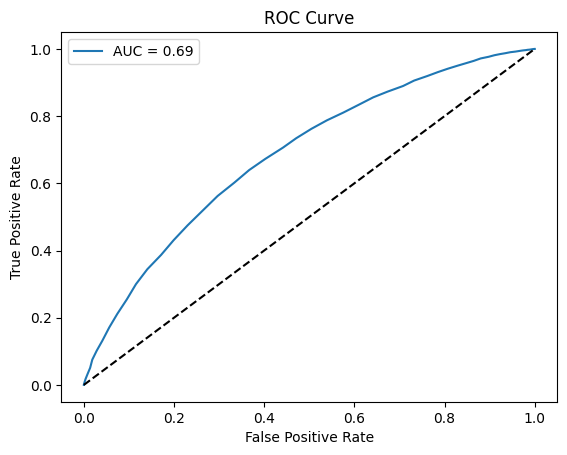

In [ ]:
# ahora el area bajo la curva ROC y pintamos la curva ROC
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(y_test, prob_predicted)
print(f"AUC: {auc}")
fpr, tpr, thresholds = roc_curve(y_test, prob_predicted)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


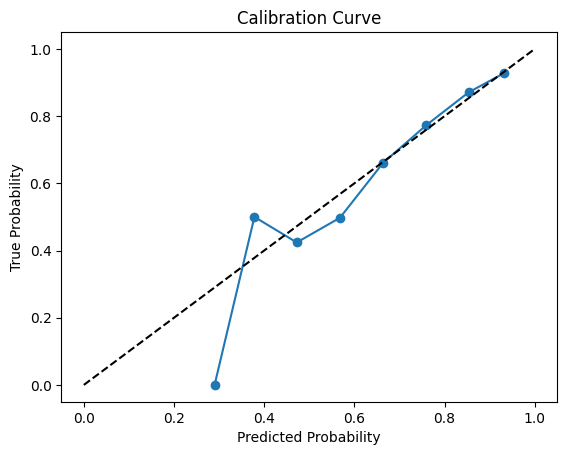

In [ ]:
# por ultimos calibracion de probabilidades, con una curva de calibracion
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, prob_predicted, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve')
plt.show()

In [ ]:
# Vamos a redefinir el problema. 
# la clase positiva es: el cliente será un moroso? es decir, no pagará?.

# renetrenamos de nuevo:
y_train_moroso = df_train[y_var] != 'Fully Paid'
rf_model_moroso = RandomForestClassifier()
rf_model_moroso.fit(X_train, y_train_moroso)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
rf_model_moroso.score(X_train, y_train_moroso)

0.9999875

In [ ]:
#evaluamos
y_test_moroso = test_df[y_var] != 'Fully Paid'
rf_model_moroso.score(X_test, y_test_moroso)

0.80215

In [ ]:
# hacemos un predict.
class_predicted_moroso = rf_model_moroso.predict(X_test)
prob_predicted_moroso = rf_model_moroso.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test_moroso, class_predicted_moroso))

              precision    recall  f1-score   support

       False       0.80      1.00      0.89     16003
        True       0.71      0.02      0.03      3997

    accuracy                           0.80     20000
   macro avg       0.76      0.51      0.46     20000
weighted avg       0.78      0.80      0.72     20000



AUC: 0.6866781420815345


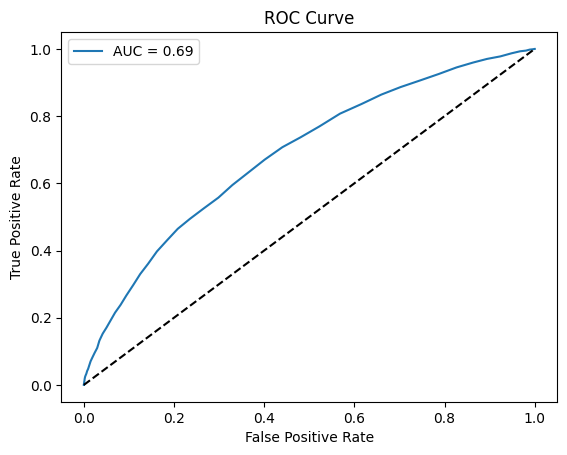

In [ ]:
# ahora el area bajo la curva ROC y pintamos la curva ROC
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(y_test_moroso, prob_predicted_moroso)
print(f"AUC: {auc}")
fpr, tpr, thresholds = roc_curve(y_test_moroso, prob_predicted_moroso)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

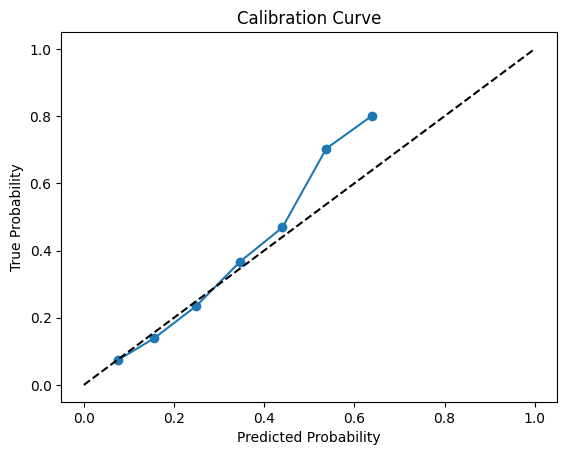

In [ ]:
# por ultimos calibracion de probabilidades, con una curva de calibracion
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test_moroso, prob_predicted_moroso, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve')
plt.show()